In [ ]:
#importing the required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [4]:
# loading MNIST dataset
# dataset has images of handwritten digits from 0 to 9
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# change images from 28x28 to 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Testing data shape: (10000, 784)


In [ ]:
# build a simple baseline model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# train the model

start_time = time.time()
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)
training_time = time.time() - start_time
print("Training time:", round(training_time, 2), "seconds")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9254 - loss: 0.2518 - val_accuracy: 0.9665 - val_loss: 0.1104
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9673 - loss: 0.1065 - val_accuracy: 0.9767 - val_loss: 0.0792
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9773 - loss: 0.0740 - val_accuracy: 0.9767 - val_loss: 0.0809
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9819 - loss: 0.0571 - val_accuracy: 0.9773 - val_loss: 0.0764
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9852 - loss: 0.0443 - val_accuracy: 0.9797 - val_loss: 0.0717
Training time: 45.06 seconds


In [ ]:
# testing the baseline model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Baseline Model Accuracy:", round(test_accuracy * 100, 2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0820
Baseline Model Accuracy: 97.74 %


In [ ]:
# save the model
model.save("baseline_mnist_model.h5")
baseline_size = os.path.getsize("baseline_mnist_model.h5") / 1024
print("Baseline Model Size:", round(baseline_size, 2), "KB")

Baseline Model Size: 1312.23 KB


In [ ]:
# Convert baseline model to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("baseline_model.tflite", "wb") as f:
    f.write(tflite_model)

tflite_size = os.path.getsize("baseline_model.tflite") / 1024
print("TFLite Model Size:", round(tflite_size, 2), "KB")

Saved artifact at '/tmp/tmpykm_dbi6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136371097314576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097315728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097314384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097310352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097316304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097313040: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite Model Size: 429.34 KB


In [ ]:
# apply quantization

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

quantized_model = converter.convert()

with open("quantized_model.tflite", "wb") as f:
    f.write(quantized_model)

quantized_size = os.path.getsize("quantized_model.tflite") / 1024
print("Quantized Model Size:", round(quantized_size, 2), "KB")

Saved artifact at '/tmp/tmprsqrbs7m'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136371097314576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097315728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097314384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097310352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097316304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136371097313040: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized Model Size: 113.64 KB


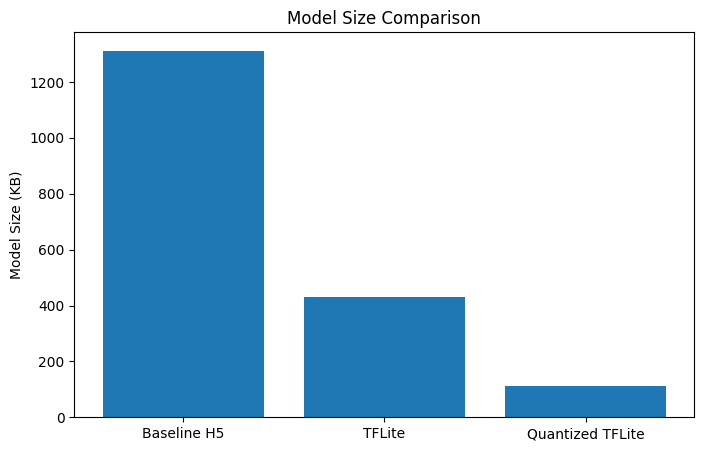

In [ ]:
# comparison of model sizes

models = ["Baseline H5", "TFLite", "Quantized TFLite"]
sizes = [baseline_size, tflite_size, quantized_size]

plt.figure(figsize=(8,5))
plt.bar(models, sizes)
plt.ylabel("Model Size (KB)")
plt.title("Model Size Comparison")
plt.show()

In [12]:
# Print final comparison table

print("Final Comparison")
print("----------------")
print("Baseline Accuracy:", round(test_accuracy * 100, 2), "%")
print("Training Time:", round(training_time, 2), "seconds")
print("Baseline H5 Size:", round(baseline_size, 2), "KB")
print("TFLite Size:", round(tflite_size, 2), "KB")
print("Quantized TFLite Size:", round(quantized_size, 2), "KB")

reduction = ((tflite_size - quantized_size) / tflite_size) * 100
print("Size Reduction after Quantization:", round(reduction, 2), "%")

Final Comparison
----------------
Baseline Accuracy: 97.74 %
Training Time: 45.06 seconds
Baseline H5 Size: 1312.23 KB
TFLite Size: 429.34 KB
Quantized TFLite Size: 113.64 KB
Size Reduction after Quantization: 73.53 %
